# 04_ModelComparison_Meta

폴더명에서 **TS(Travel Speed)**, **WFR(Wire Feed Rate)** 추출 → 시계열 전 구간에 상수 피처로 추가.  
피처: `[V, I, TS, WFR]` (4채널, 윈도우 shape = (N, 30, 4))

| 피처 | 설명 | 정규화 |
|---|---|---|
| V, I | 시계열 (Avg Voltage / Current) | trial z-score → global scaler |
| TS, WFR | trial 상수 (폴더명 파싱) | global scaler (raw값) |

**모델 비교**: LSTM vs RNN (3-Fold Stratified CV 하이퍼파라미터 탐색, epoch = CV fold 평균)

In [1]:
from pathlib import Path

BASE_DIR  = Path.home() / 'Desktop' / 'ai1' / 'original_INC_202501'
MODEL_DIR = Path.home() / 'Desktop' / 'ai1' / 'meta_model'
MODEL_DIR.mkdir(exist_ok=True)

SENSOR_INTERVAL = 0.1
WINDOW_DURATION = 3.0
STEP_DURATION   = 1.0
WINDOW_SIZE = int(WINDOW_DURATION / SENSOR_INTERVAL)   # 30
STEP_SIZE   = int(STEP_DURATION   / SENSOR_INTERVAL)   # 10
FEATURES    = ['Avg Voltage', 'Avg Current']

NORMAL_TEST_IDS   = {1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 28, 29, 30, 44}
ABNORMAL_TEST_IDS = {6, 31, 45} | set(range(32, 44))
NORMAL_VAL_IDS    = set(range(3, 10))
ABNORMAL_VAL_IDS  = {1, 2}
VAL_TRIAL_IDS     = {44, 45}

EPOCHS              = 200
EARLY_STOP_PATIENCE = 20
RANDOM_SEED         = 42
N_ITER              = 20
CV_EPOCHS           = 100
CV_PATIENCE         = 10

print(f'WINDOW_SIZE: {WINDOW_SIZE},  STEP_SIZE: {STEP_SIZE}')

WINDOW_SIZE: 30,  STEP_SIZE: 10


In [2]:
import re, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report,
                              roc_auc_score, roc_curve,
                              average_precision_score, precision_recall_curve,
                              f1_score, precision_score, recall_score)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cv3    = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

print('PyTorch :', torch.__version__)
print('Device  :', DEVICE)

PyTorch : 2.11.0+cu128
Device  : cuda


In [3]:
# =========================
# 데이터 로드
# V, I: trial z-score (DC 제거)
# TS, WFR: 폴더명 파싱 → 상수 열로 추가 (raw, 글로벌 scaler로만 정규화)
# =========================

def parse_folder_id(name):
    m = re.match(r'^(Test|Val)(\d+)_', name, flags=re.IGNORECASE)
    if not m: return None, None
    return m.group(1).capitalize(), int(m.group(2))

def parse_meta(name):
    m = re.search(r'_(\d+)TS_(\d+)WFR', name, re.IGNORECASE)
    if not m: return None, None
    return float(m.group(1)), float(m.group(2))

def get_label(prefix, idx):
    if prefix == 'Test':
        if idx in NORMAL_TEST_IDS:   return 0
        if idx in ABNORMAL_TEST_IDS: return 1
    elif prefix == 'Val':
        if idx in NORMAL_VAL_IDS:    return 0
        if idx in ABNORMAL_VAL_IDS:  return 1
    raise ValueError()

def get_split(prefix, idx):
    if prefix == 'Val':          return 'test'
    if prefix == 'Test':
        if idx in VAL_TRIAL_IDS: return 'val'
        return 'train'
    raise ValueError()

records = []
for d in sorted(BASE_DIR.iterdir()):
    if not d.is_dir(): continue
    prefix, idx = parse_folder_id(d.name)
    if prefix is None: continue
    ts, wfr = parse_meta(d.name)
    if ts is None:
        print(f'[SKIP] TS/WFR 파싱 실패: {d.name}'); continue
    try:
        label = get_label(prefix, idx)
        split = get_split(prefix, idx)
    except ValueError:
        continue
    csvs = list(d.glob('*.csv'))
    if not csvs: continue

    vi = pd.read_csv(csvs[0])[FEATURES].astype(float).values  # (n, 2)
    mean, std = vi.mean(0), vi.std(0)
    std[std < 1e-8] = 1e-8
    vi_norm = (vi - mean) / std  # trial z-score

    n = len(vi_norm)
    ts_col  = np.full((n, 1), ts,  dtype=np.float64)
    wfr_col = np.full((n, 1), wfr, dtype=np.float64)
    data = np.hstack([vi_norm, ts_col, wfr_col]).astype(np.float32)  # (n, 4)

    records.append({'folder': d.name, 'label': label, 'split': split,
                    'data': data, 'ts': ts, 'wfr': wfr})
    print(f'{d.name:45s}  {split:5s}  label={label}  TS={int(ts):2d}  WFR={int(wfr):3d}')

summary = pd.DataFrame([{k: r[k] for k in ('folder','split','label','ts','wfr')} for r in records])
print('\n=== Split 요약 ===')
print(summary.groupby(['split','label']).size().rename('n_trials'))

Test1_160A_20TS_160WFR                         train  label=0  TS=20  WFR=160
Test2_160A_20TS_190WFR                         train  label=0  TS=20  WFR=190
Test31_120A_20TS_160WFR                        train  label=1  TS=20  WFR=160
Test32_120A_20TS_190WFR                        train  label=1  TS=20  WFR=190
Test34_120A_30TS_190WFR                        train  label=1  TS=30  WFR=190
Test38_140A_30TS_180WFR                        train  label=1  TS=30  WFR=180
Test3_160A_30TS_160WFR                         train  label=0  TS=30  WFR=160
Test41_140A_25TS_180WFR                        train  label=1  TS=25  WFR=180
Test43_150A_30TS_190WFR                        train  label=1  TS=30  WFR=190
Test44_150A_25TS_160WFR                        val    label=0  TS=25  WFR=160
Test45_150A_25TS_180WFR                        val    label=1  TS=25  WFR=180
Test5_160A_40TS_160WFR                         train  label=0  TS=40  WFR=160
Test7_180A_20TS_160WFR                         train  label=0  T

In [4]:
# =========================
# 슬라이딩 윈도우 생성
# =========================

def make_windows(data, ws, ss):
    return np.stack([data[s:s+ws] for s in range(0, len(data)-ws+1, ss)])

buckets = {'train': ([], []), 'val': ([], []), 'test': ([], [])}
for r in records:
    wins   = make_windows(r['data'], WINDOW_SIZE, STEP_SIZE)
    labels = np.full(len(wins), r['label'], dtype=np.float32)
    buckets[r['split']][0].append(wins)
    buckets[r['split']][1].append(labels)

X = {s: np.vstack(buckets[s][0]).astype(np.float32) for s in buckets}
y = {s: np.concatenate(buckets[s][1]) for s in buckets}

FEAT_NAMES = ['V', 'I', 'TS', 'WFR']
n_feat = X['train'].shape[2]   # 4

for s in ('train', 'val', 'test'):
    u, c = np.unique(y[s], return_counts=True)
    cnt  = dict(zip(u.astype(int), c))
    print(f'{s:5s}  shape={X[s].shape}  normal={cnt.get(0,0):4d}  abnormal={cnt.get(1,0):4d}')

train  shape=(364, 30, 4)  normal= 183  abnormal= 181
val    shape=(58, 30, 4)  normal=  29  abnormal=  29
test   shape=(150, 30, 4)  normal=  95  abnormal=  55


In [5]:
# =========================
# 글로벌 StandardScaler (4 피처 전부)
# V, I: 이미 trial z-score → 미세 조정
# TS, WFR: raw 값 → 이 단계에서 정규화
# =========================

scaler = StandardScaler()
scaler.fit(X['train'].reshape(-1, n_feat))

def scale(arr):
    n, w, f = arr.shape
    return scaler.transform(arr.reshape(-1, f)).reshape(n, w, f).astype(np.float32)

Xs = {s: scale(X[s]) for s in X}

print('=== 글로벌 스케일러 (train 기준) ===')
for i, name in enumerate(FEAT_NAMES):
    print(f'  {name:5s}  mean={scaler.mean_[i]:+8.4f}  std={scaler.scale_[i]:.4f}')
print(f'\nX_train: {Xs["train"].shape}')
print(f'X_val  : {Xs["val"].shape}')
print(f'X_test : {Xs["test"].shape}')

=== 글로벌 스케일러 (train 기준) ===
  V      mean= +0.0204  std=0.6635
  I      mean= +0.0815  std=0.2982
  TS     mean=+24.0659  std=5.6043
  WFR    mean=+176.0989  std=13.8933

X_train: (364, 30, 4)
X_val  : (58, 30, 4)
X_test : (150, 30, 4)


In [6]:
# =========================
# Dataset / test_loader / CV용 train+val
# =========================

class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

test_loader = DataLoader(WindowDataset(Xs['test'], y['test']), batch_size=64, shuffle=False)

Xs_tv = np.vstack([Xs['train'], Xs['val']])
ys_tv = np.concatenate([y['train'], y['val']]).astype(np.float32)

print(f'Xs_tv : {Xs_tv.shape}  (0={int((ys_tv==0).sum())}, 1={int((ys_tv==1).sum())})')
print(f'X_test: {Xs["test"].shape}')

Xs_tv : (422, 30, 4)  (0=212, 1=210)
X_test: (150, 30, 4)


In [7]:
# =========================
# 공통 평가 함수 (window-level, threshold=0.5)
# =========================

roc_data = {}
results  = {}

def evaluate(model_name, model_obj, loader):
    model_obj.eval()
    probs, trues = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            probs.append(model_obj(Xb.to(DEVICE)).cpu().numpy())
            trues.append(yb.numpy())
    y_prob = np.concatenate(probs)
    y_true = np.concatenate(trues).astype(int)
    y_pred = (y_prob >= 0.5).astype(int)

    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc  = average_precision_score(y_true, y_prob)

    print(f'\n===== {model_name} (threshold=0.5) =====')
    print(classification_report(y_true, y_pred,
                                target_names=['Normal(0)', 'Abnormal(1)'],
                                zero_division=0))
    print(f'ROC-AUC : {roc_auc:.4f}  |  PR-AUC : {pr_auc:.4f}')

    roc_data[model_name] = (y_true, y_prob)
    results[model_name]  = {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'roc_auc':   roc_auc,
        'pr_auc':    pr_auc,
    }

print('평가 함수 준비 완료')

평가 함수 준비 완료


In [8]:
# =========================
# 공통 CV 탐색 함수
# =========================

def run_cv_search(ModelClass, param_dist, label):
    random.seed(RANDOM_SEED)
    sampled = [{k: random.choice(v) for k, v in param_dist.items()}
               for _ in range(N_ITER)]

    crit          = nn.BCELoss()
    cv_results    = []
    best_cv_auc   = -1
    best_params   = None

    for i, params in enumerate(sampled):
        fold_aucs, fold_epochs = [], []

        for tr_idx, vl_idx in cv3.split(Xs_tv, ys_tv.astype(int)):
            X_tr, X_vl = Xs_tv[tr_idx], Xs_tv[vl_idx]
            y_tr, y_vl = ys_tv[tr_idx], ys_tv[vl_idx]

            mdl = ModelClass(n_feat, params['hidden1'],
                             params['hidden2'], params['dropout']).to(DEVICE)
            opt = torch.optim.Adam(mdl.parameters(), lr=params['lr'])
            tr_dl = DataLoader(WindowDataset(X_tr, y_tr), params['batch_size'], shuffle=True)
            vl_dl = DataLoader(WindowDataset(X_vl, y_vl), params['batch_size'])

            best_loss = float('inf'); pc = 0; best_ep = 1
            for ep in range(1, CV_EPOCHS + 1):
                mdl.train()
                for Xb, yb in tr_dl:
                    Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                    opt.zero_grad(); crit(mdl(Xb), yb).backward(); opt.step()
                mdl.eval()
                with torch.no_grad():
                    vl_loss = (sum(crit(mdl(Xb.to(DEVICE)), yb.to(DEVICE)).item() * len(yb)
                                   for Xb, yb in vl_dl) / len(vl_dl.dataset))
                if vl_loss < best_loss:
                    best_loss = vl_loss; pc = 0; best_ep = ep
                else:
                    pc += 1
                    if pc >= CV_PATIENCE: break

            fold_epochs.append(best_ep)
            mdl.eval()
            probs, trues = [], []
            with torch.no_grad():
                for Xb, yb in vl_dl:
                    probs.append(mdl(Xb.to(DEVICE)).cpu().numpy())
                    trues.append(yb.numpy())
            try:
                auc = roc_auc_score(np.concatenate(trues).astype(int), np.concatenate(probs))
            except Exception:
                auc = 0.5
            fold_aucs.append(auc)

        mean_auc = float(np.mean(fold_aucs))
        avg_ep   = int(round(np.mean(fold_epochs)))
        cv_results.append({'params': params, 'cv_auc': mean_auc,
                           'fold_epochs': fold_epochs, 'avg_epoch': avg_ep})
        print(f'[{label}] [{i+1:2d}/{N_ITER}] '
              f'h1={params["hidden1"]:3d} h2={params["hidden2"]:2d} '
              f'drop={params["dropout"]} lr={params["lr"]} bs={params["batch_size"]:2d} '
              f'| AUC={mean_auc:.4f}  epochs={fold_epochs}→avg={avg_ep}')

        if mean_auc > best_cv_auc:
            best_cv_auc = mean_auc
            best_params = params

    best_result = next(r for r in cv_results if r['params'] == best_params)
    print(f'\n[{label}] 최적 파라미터  : {best_params}')
    print(f'[{label}] CV best AUC    : {best_cv_auc:.4f}')
    print(f'[{label}] 최종 학습 epoch: {best_result["avg_epoch"]}  (CV fold 평균)')
    return best_params, best_result['avg_epoch']


def train_final(ModelClass, best_params, avg_epoch, save_name):
    model = ModelClass(n_feat, best_params['hidden1'],
                       best_params['hidden2'], best_params['dropout']).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=best_params['lr'])
    crit  = nn.BCELoss()
    dl    = DataLoader(WindowDataset(Xs_tv, ys_tv), best_params['batch_size'], shuffle=True)
    path  = str(MODEL_DIR / save_name)
    history = []

    print(f'\n학습 epoch: {avg_epoch}')
    for epoch in range(1, avg_epoch + 1):
        model.train()
        tr_loss = 0
        for Xb, yb in dl:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(Xb), yb)
            loss.backward(); opt.step()
            tr_loss += loss.item() * len(yb)
        tr_loss /= len(dl.dataset)
        history.append(tr_loss)
        if epoch % 20 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{avg_epoch}  loss={tr_loss:.4f}')

    torch.save(model.state_dict(), path)
    print(f'저장 완료: {path}')
    return model, history


print('CV 탐색 / 최종 학습 함수 준비 완료')

CV 탐색 / 최종 학습 함수 준비 완료


In [9]:
# =========================
# LSTM 모델 정의
# =========================

class LSTMAnomalyDetector(nn.Module):
    def __init__(self, n_features, hidden1, hidden2, dropout):
        super().__init__()
        self.lstm1 = nn.LSTM(n_features, hidden1, batch_first=True)
        self.drop1 = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.drop2 = nn.Dropout(dropout)
        self.fc    = nn.Linear(hidden2, 1)

    def forward(self, x):
        out, _ = self.lstm1(x);  out = self.drop1(out)
        out, _ = self.lstm2(out)
        return torch.sigmoid(self.fc(self.drop2(out[:, -1, :]))).squeeze(-1)


lstm_param_dist = {
    'hidden1':    [32, 64, 128],
    'hidden2':    [16, 32, 64],
    'dropout':    [0.2, 0.3, 0.5],
    'lr':         [1e-3, 5e-4],
    'batch_size': [16, 32],
}

print('LSTM 탐색 시작...')
lstm_best_params, lstm_avg_epoch = run_cv_search(LSTMAnomalyDetector, lstm_param_dist, 'LSTM')

LSTM 탐색 시작...
[LSTM] [ 1/20] h1=128 h2=16 drop=0.2 lr=0.0005 bs=16 | AUC=0.9168  epochs=[66, 17, 35]→avg=39
[LSTM] [ 2/20] h1= 32 h2=16 drop=0.5 lr=0.001 bs=16 | AUC=0.9754  epochs=[20, 72, 49]→avg=47
[LSTM] [ 3/20] h1=128 h2=32 drop=0.2 lr=0.001 bs=16 | AUC=0.9101  epochs=[13, 23, 23]→avg=20
[LSTM] [ 4/20] h1= 32 h2=16 drop=0.5 lr=0.001 bs=16 | AUC=0.9701  epochs=[33, 65, 26]→avg=41
[LSTM] [ 5/20] h1=128 h2=64 drop=0.5 lr=0.0005 bs=16 | AUC=0.9233  epochs=[23, 25, 33]→avg=27
[LSTM] [ 6/20] h1= 64 h2=64 drop=0.3 lr=0.001 bs=16 | AUC=0.8729  epochs=[7, 13, 10]→avg=10
[LSTM] [ 7/20] h1=128 h2=32 drop=0.3 lr=0.0005 bs=16 | AUC=0.8748  epochs=[22, 19, 63]→avg=35
[LSTM] [ 8/20] h1= 32 h2=32 drop=0.2 lr=0.001 bs=32 | AUC=0.9459  epochs=[64, 24, 50]→avg=46
[LSTM] [ 9/20] h1= 32 h2=32 drop=0.3 lr=0.0005 bs=16 | AUC=0.9519  epochs=[55, 45, 46]→avg=49
[LSTM] [10/20] h1=128 h2=32 drop=0.5 lr=0.001 bs=32 | AUC=0.6729  epochs=[5, 6, 24]→avg=12
[LSTM] [11/20] h1= 32 h2=64 drop=0.3 lr=0.0005 bs=16 | 


학습 epoch: 70
  Epoch   1/70  loss=0.6911
  Epoch  20/70  loss=0.3313
  Epoch  40/70  loss=0.0907
  Epoch  60/70  loss=0.0762
저장 완료: C:\Users\ehdrmsdua\Desktop\ai1\meta_model\best_lstm.pt


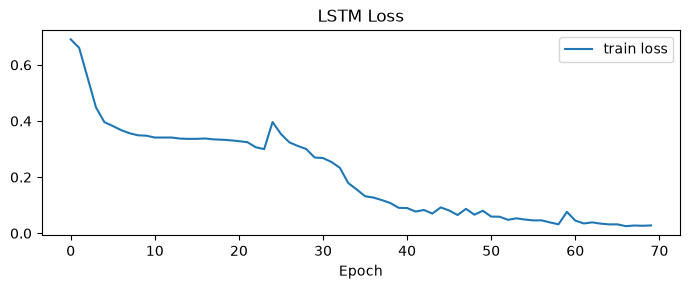

In [10]:
# LSTM 최종 학습
lstm_model, lstm_history = train_final(LSTMAnomalyDetector, lstm_best_params,
                                        lstm_avg_epoch, 'best_lstm.pt')
plt.figure(figsize=(7, 3))
plt.plot(lstm_history, label='train loss')
plt.title('LSTM Loss'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.savefig(str(MODEL_DIR / 'lstm_loss.png'), dpi=150); plt.show()

In [11]:
# LSTM 평가
evaluate('LSTM', lstm_model, test_loader)


===== LSTM (threshold=0.5) =====
              precision    recall  f1-score   support

   Normal(0)       0.69      0.57      0.62        95
 Abnormal(1)       0.43      0.56      0.49        55

    accuracy                           0.57       150
   macro avg       0.56      0.57      0.56       150
weighted avg       0.60      0.57      0.57       150

ROC-AUC : 0.5171  |  PR-AUC : 0.4257


In [12]:
# =========================
# RNN 모델 정의
# =========================

class RNNAnomalyDetector(nn.Module):
    def __init__(self, n_features, hidden1, hidden2, dropout):
        super().__init__()
        self.rnn1  = nn.RNN(n_features, hidden1, batch_first=True, nonlinearity='tanh')
        self.drop1 = nn.Dropout(dropout)
        self.rnn2  = nn.RNN(hidden1, hidden2, batch_first=True, nonlinearity='tanh')
        self.drop2 = nn.Dropout(dropout)
        self.fc    = nn.Linear(hidden2, 1)

    def forward(self, x):
        out, _ = self.rnn1(x);  out = self.drop1(out)
        out, _ = self.rnn2(out)
        return torch.sigmoid(self.fc(self.drop2(out[:, -1, :]))).squeeze(-1)


rnn_param_dist = {
    'hidden1':    [32, 64, 128],
    'hidden2':    [16, 32, 64],
    'dropout':    [0.2, 0.3, 0.5],
    'lr':         [1e-3, 5e-4],
    'batch_size': [16, 32],
}

print('RNN 탐색 시작...')
rnn_best_params, rnn_avg_epoch = run_cv_search(RNNAnomalyDetector, rnn_param_dist, 'RNN')

RNN 탐색 시작...
[RNN] [ 1/20] h1=128 h2=16 drop=0.2 lr=0.0005 bs=16 | AUC=0.8078  epochs=[13, 31, 18]→avg=21
[RNN] [ 2/20] h1= 32 h2=16 drop=0.5 lr=0.001 bs=16 | AUC=0.9467  epochs=[62, 75, 43]→avg=60
[RNN] [ 3/20] h1=128 h2=32 drop=0.2 lr=0.001 bs=16 | AUC=0.8485  epochs=[21, 31, 28]→avg=27
[RNN] [ 4/20] h1= 32 h2=16 drop=0.5 lr=0.001 bs=16 | AUC=0.8795  epochs=[73, 6, 34]→avg=38
[RNN] [ 5/20] h1=128 h2=64 drop=0.5 lr=0.0005 bs=16 | AUC=0.8747  epochs=[32, 6, 45]→avg=28
[RNN] [ 6/20] h1= 64 h2=64 drop=0.3 lr=0.001 bs=16 | AUC=0.8886  epochs=[45, 10, 18]→avg=24
[RNN] [ 7/20] h1=128 h2=32 drop=0.3 lr=0.0005 bs=16 | AUC=0.7584  epochs=[18, 46, 22]→avg=29
[RNN] [ 8/20] h1= 32 h2=32 drop=0.2 lr=0.001 bs=32 | AUC=0.8385  epochs=[37, 35, 51]→avg=41
[RNN] [ 9/20] h1= 32 h2=32 drop=0.3 lr=0.0005 bs=16 | AUC=0.9183  epochs=[36, 49, 70]→avg=52
[RNN] [10/20] h1=128 h2=32 drop=0.5 lr=0.001 bs=32 | AUC=0.7747  epochs=[4, 18, 34]→avg=19
[RNN] [11/20] h1= 32 h2=64 drop=0.3 lr=0.0005 bs=16 | AUC=0.8117  


학습 epoch: 60
  Epoch   1/60  loss=0.6875
  Epoch  20/60  loss=0.4209
  Epoch  40/60  loss=0.3969
  Epoch  60/60  loss=0.3611
저장 완료: C:\Users\ehdrmsdua\Desktop\ai1\meta_model\best_rnn.pt


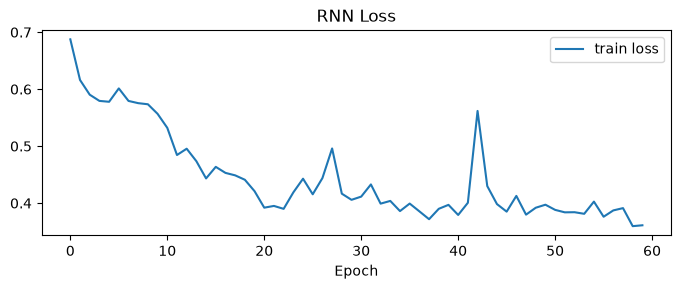

In [13]:
# RNN 최종 학습
rnn_model, rnn_history = train_final(RNNAnomalyDetector, rnn_best_params,
                                      rnn_avg_epoch, 'best_rnn.pt')
plt.figure(figsize=(7, 3))
plt.plot(rnn_history, label='train loss')
plt.title('RNN Loss'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.savefig(str(MODEL_DIR / 'rnn_loss.png'), dpi=150); plt.show()

In [14]:
# RNN 평가
evaluate('RNN', rnn_model, test_loader)


===== RNN (threshold=0.5) =====
              precision    recall  f1-score   support

   Normal(0)       0.79      0.96      0.87        95
 Abnormal(1)       0.89      0.56      0.69        55

    accuracy                           0.81       150
   macro avg       0.84      0.76      0.78       150
weighted avg       0.83      0.81      0.80       150

ROC-AUC : 0.5851  |  PR-AUC : 0.7053


=== Window-level 비교 (V, I, TS, WFR | threshold=0.5) ===
Model  Precision  Recall    F1  ROC-AUC  PR-AUC
 LSTM      0.431   0.564 0.488    0.517   0.426
  RNN      0.886   0.564 0.689    0.585   0.705


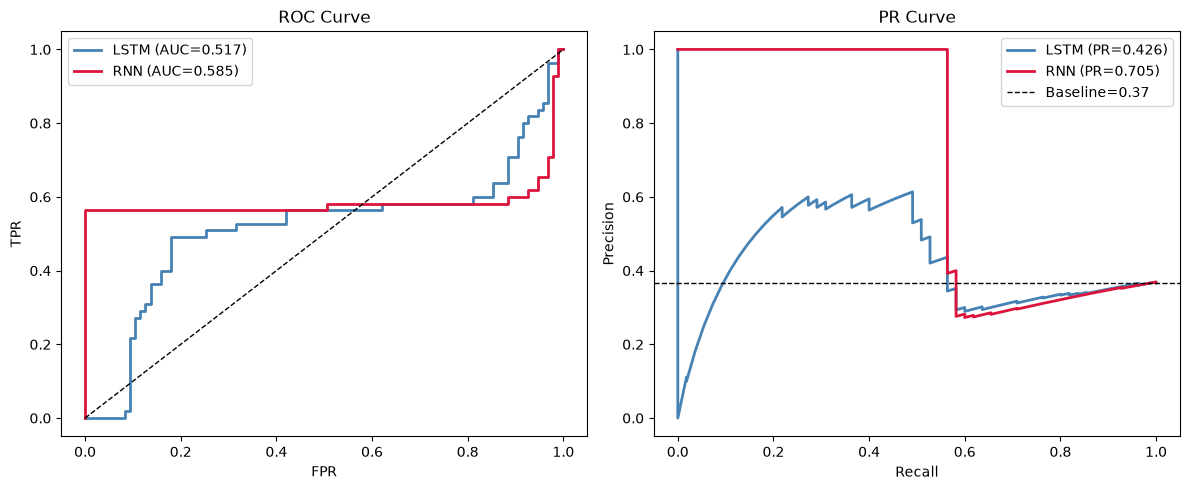

In [15]:
# =========================
# 비교 요약 + ROC/PR 곡선
# =========================

df = pd.DataFrame([
    {'Model': name, 'Precision': round(v['precision'], 3), 'Recall': round(v['recall'], 3),
     'F1': round(v['f1'], 3), 'ROC-AUC': round(v['roc_auc'], 3), 'PR-AUC': round(v['pr_auc'], 3)}
    for name, v in results.items()
])
print('=== Window-level 비교 (V, I, TS, WFR | threshold=0.5) ===')
print(df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['steelblue', 'crimson']

for (name, (yt, yp)), c in zip(roc_data.items(), colors):
    fpr, tpr, _ = roc_curve(yt, yp)
    axes[0].plot(fpr, tpr, lw=2, color=c, label=f'{name} (AUC={roc_auc_score(yt,yp):.3f})')
    pre, rec, _ = precision_recall_curve(yt, yp)
    axes[1].plot(rec, pre, lw=2, color=c, label=f'{name} (PR={average_precision_score(yt,yp):.3f})')

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend()

baseline = list(roc_data.values())[0][0].mean()
axes[1].axhline(baseline, color='k', linestyle='--', lw=1, label=f'Baseline={baseline:.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve'); axes[1].legend()

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'comparison.png'), dpi=150)
plt.show()

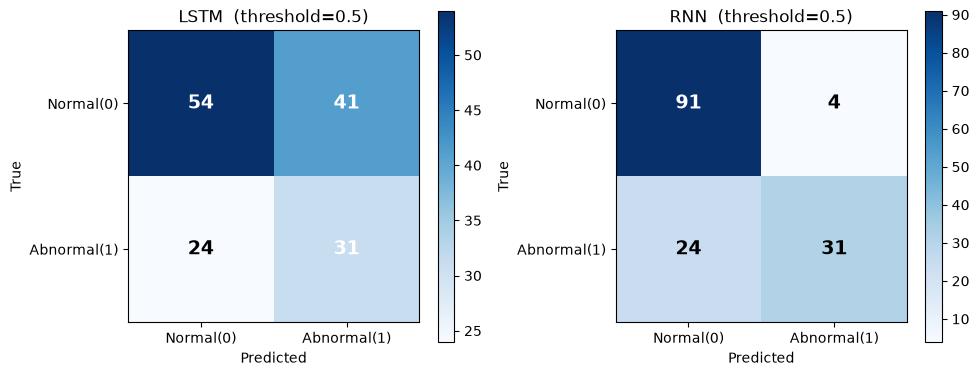

In [16]:
# =========================
# 혼동행렬 (LSTM vs RNN 나란히)
# =========================

from sklearn.metrics import confusion_matrix
import itertools

def plot_cm(ax, y_true, y_prob, title):
    y_pred = (y_prob >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=[0, 1], yticks=[0, 1],
           xticklabels=['Normal(0)', 'Abnormal(1)'],
           yticklabels=['Normal(0)', 'Abnormal(1)'],
           xlabel='Predicted', ylabel='True', title=title)
    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, f'{cm[i, j]}',
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=14, fontweight='bold')

fig, axes = plt.subplots(1, len(roc_data), figsize=(5 * len(roc_data), 4))
if len(roc_data) == 1:
    axes = [axes]

for ax, (name, (y_true, y_prob)) in zip(axes, roc_data.items()):
    plot_cm(ax, y_true, y_prob, f'{name}  (threshold=0.5)')

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'confusion_matrix.png'), dpi=150)
plt.show()